# Week 2 — Hidden state estimation (JAX)

The NumPy notebook does the week one run at a time. This one does three things
that only become practical when you can run thousands of copies at once, and
one thing that only becomes practical when the machine differentiates for you.

1. **Check the derivation.** `jax.grad` computes the gradient of the log joint
   without being told the answer. Comparing it against the two prediction
   errors derived by hand in Lesson 3 is a real check on the algebra.
2. **Map the basins.** The bimodal case of the problems page has two peaks.
   Which one gradient ascent finds depends on where it starts. `vmap` runs
   ten thousand starting points at once and draws the map.
3. **Sweep the precision plane.** How the estimate moves as the two
   precisions vary, over a grid of both at the same time.

If you are new to JAX, the three things to know are that `jit` compiles a
function, `vmap` turns a function of one thing into a function of many, and
arrays are immutable.

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import numpy as np
import matplotlib.pyplot as plt

jax.config.update('jax_enable_x64', True)   # the checks below need it
print(jax.__version__, jax.devices())

0.6.2 [CpuDevice(id=0)]


## 1. Does the derivation hold up?

Lesson 3 differentiated the log joint by hand and got

    dF/dd = (d_p - d)/var_p  +  (u - g(d))/var_u * g'(d)

Write down only `F` and let JAX differentiate it. If the two disagree,
the algebra is wrong, and this is the cheapest way to find out.

In [2]:
d_p, var_p = 2.0, 1.0
u,   var_u = 0.50, 0.10

g       = lambda d: 1.0 / d**2
g_prime = lambda d: -2.0 / d**3


def log_joint(d):
    """ln P(d) + ln P(u | d), constants dropped."""
    return (-(d - d_p)**2 / (2*var_p)
            - (u - g(d))**2 / (2*var_u))


def by_hand(d):
    return (d_p - d)/var_p + (u - g(d))/var_u * g_prime(d)


auto = vmap(grad(log_joint))
ds   = jnp.linspace(0.3, 6.0, 2001)
gap  = jnp.abs(auto(ds) - vmap(by_hand)(ds))

print(f'largest disagreement over 2001 points: {gap.max():.3e}')
print(f'largest gradient magnitude:            {jnp.abs(auto(ds)).max():.3e}')

largest disagreement over 2001 points: 1.819e-12
largest gradient magnitude:            7.862e+03


Agreement at the level of floating-point noise, across a range where the
gradient itself reaches into the hundreds. The chain rule was applied
correctly and the sign of the `g'` factor is right.

This is worth doing every time you derive an update rule by hand. It costs
three lines and it checks the step most likely to be wrong.

## 2. Mapping the basins of attraction

The problems page uses a setting where the log joint has two peaks. Ascent
from the prior mean finds the lower one and stops there, with nothing in the
run to signal that a taller peak exists elsewhere.

Which peak you get depends on where you start, and the dependence is not
simple. Run ten thousand starting points and look.

In [3]:
bi_d_p, bi_var_p = 4.0, 0.5
bi_u,   bi_var_u = 1.5, 0.1


@jit
def bi_ascend(d0, eta=0.02, steps=6000):
    def step(d, _):
        d = d + eta * ((bi_d_p - d)/bi_var_p
                       + (bi_u - g(d))/bi_var_u * g_prime(d))
        return jnp.clip(d, 0.05, 10.0), None
    final, _ = jax.lax.scan(step, d0, None, length=steps)
    return final


starts  = jnp.linspace(0.06, 9.99, 10_000)
endings = vmap(bi_ascend)(starts)

peaks = jnp.unique(jnp.round(endings, 3))
print('distinct resting points:', np.asarray(peaks))

distinct resting points: [0.882 3.723]


89.5% of starting points end on the SHORTER peak:
a local maximum that is not the MAP estimate.
basin boundaries at d = [0.674 1.721]


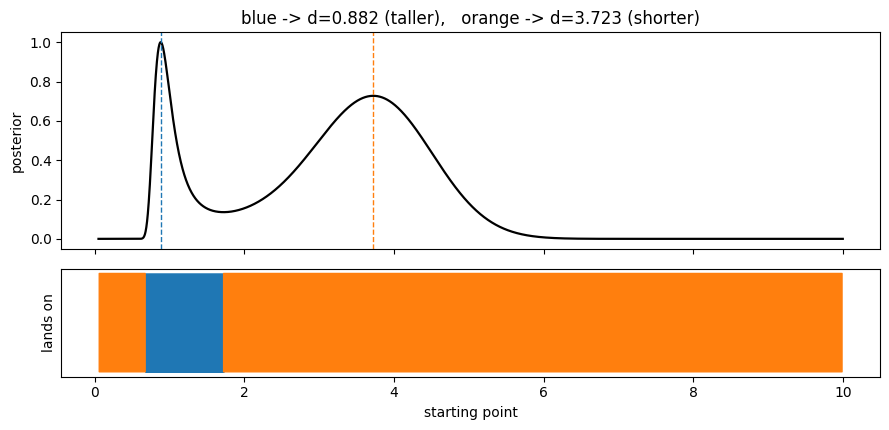

In [4]:
# The two peaks differ in BOTH position and height, and the two orderings run
# opposite ways here, so name them by height and never say 'the lower one'.
near, far = float(peaks.min()), float(peaks.max())
height = lambda d: np.exp(-(d - bi_d_p)**2/(2*bi_var_p) - (bi_u - g(d))**2/(2*bi_var_u))
tall, short = (near, far) if height(near) > height(far) else (far, near)
to_far   = np.asarray(endings) > (near + far) / 2
to_short = to_far if short == far else ~to_far

fig, ax = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True,
                       gridspec_kw={'height_ratios': [2, 1]})
grid = np.linspace(0.05, 10, 4000)
lj = np.exp(-(grid - bi_d_p)**2/(2*bi_var_p) - (bi_u - g(grid))**2/(2*bi_var_u))
ax[0].plot(grid, lj / lj.max(), color='k', lw=1.6)
ax[0].axvline(near, color='C0', ls='--', lw=1)
ax[0].axvline(far,  color='C1', ls='--', lw=1)
ax[0].set_ylabel('posterior')
ax[1].fill_between(np.asarray(starts), 0, 1, where=~to_far, color='C0', step='mid')
ax[1].fill_between(np.asarray(starts), 0, 1, where=to_far,  color='C1', step='mid')
ax[1].set_yticks([]); ax[1].set_xlabel('starting point')
ax[1].set_ylabel('lands on')
ax[0].set_title(f'blue -> d={near:.3f} (taller),   orange -> d={far:.3f} (shorter)')
plt.tight_layout()

print(f'{100*to_short.mean():.1f}% of starting points end on the SHORTER peak:')
print('a local maximum that is not the MAP estimate.')

boundaries = np.where(np.diff(to_far.astype(int)) != 0)[0]
print('basin boundaries at d =', np.round(np.asarray(starts)[boundaries], 3))

Read the lower panel. The basins are not two intervals either side of the
valley, which is what you would guess. There are two boundaries, and they are
different kinds of thing.

The upper one is the valley floor: start on one side of it and you walk uphill
to that side's peak, which is what gradient ascent is supposed to do. The lower
one is an artefact. Below it the predicted intensity is far above what was heard
and the gradient runs into the thousands, so a single step throws the estimate
clear across the range and past both peaks.

Change the rate and watch which boundary moves.

In [5]:
for eta in (0.002, 0.02, 0.05):
    e = np.asarray(vmap(lambda s: bi_ascend(s, eta=eta))(starts))
    b = np.where(np.diff((e > (near + far)/2).astype(int)) != 0)[0]
    print(f'eta {eta:<6} boundaries at d = {np.round(np.asarray(starts)[b], 3)}')

eta 0.002  boundaries at d = [0.464 1.721]
eta 0.02   boundaries at d = [0.674 1.721]
eta 0.05   boundaries at d = [0.75  1.721]


## 3. Sweeping the precision plane

Lesson 4 pushed each precision to its extremes one at a time. With `vmap`
nested twice we can see the whole plane at once: how the estimate moves as
both vary together, and how much of the mode-mean gap is where.

In [6]:
@jit
def summarise(vp, vu):
    """Mode, mean and skew of the posterior, by quadrature."""
    d = jnp.linspace(0.02, 10.0, 20_000)
    lp = -(d - d_p)**2/(2*vp) - (u - g(d))**2/(2*vu)
    p  = jnp.exp(lp - lp.max())
    p  = p / jnp.trapezoid(p, d)
    mode = d[jnp.argmax(p)]
    mean = jnp.trapezoid(d * p, d)
    sd   = jnp.sqrt(jnp.trapezoid((d - mean)**2 * p, d))
    skew = jnp.trapezoid(((d - mean)/sd)**3 * p, d)
    return mode, mean, skew


vps = jnp.geomspace(0.05, 4.0, 60)
vus = jnp.geomspace(0.005, 1.0, 60)
VP, VU = jnp.meshgrid(vps, vus, indexing='ij')

mode, mean, skew = vmap(vmap(summarise))(VP, VU)
gap = 100 * (mean - mode) / mode
print('3600 posteriors summarised; gap ranges',
      f'{gap.min():.1f}% to {gap.max():.1f}%')

3600 posteriors summarised; gap ranges 0.0% to 87.7%


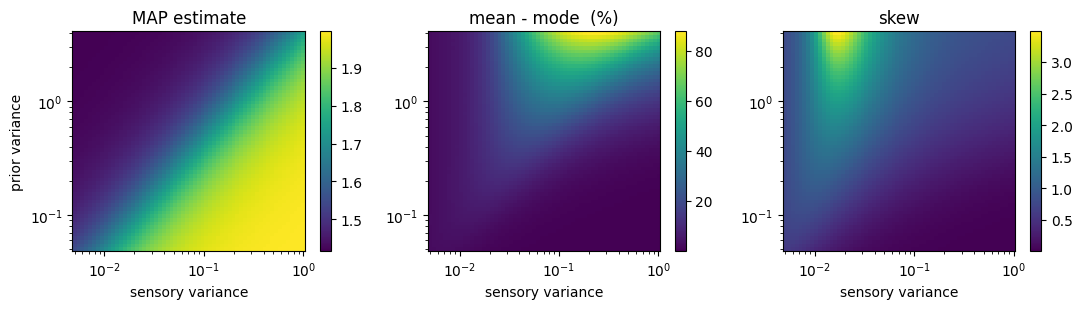

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, Z, t in ((ax[0], mode, 'MAP estimate'),
                (ax[1], gap,  'mean - mode  (%)'),
                (ax[2], skew, 'skew')):
    im = a.pcolormesh(np.asarray(vus), np.asarray(vps), np.asarray(Z),
                      shading='auto')
    a.set_xscale('log'); a.set_yscale('log')
    a.set_xlabel('sensory variance'); a.set_title(t)
    fig.colorbar(im, ax=a)
ax[0].set_ylabel('prior variance')
plt.tight_layout()

In [8]:
i, j = np.unravel_index(np.asarray(gap).argmax(), gap.shape)
print(f'largest gap {gap.max():.1f}%  at prior var {float(vps[i]):.3f},',
      f'sensory var {float(vus[j]):.4f}')
print()
for lab, (a, b) in {'broad prior, loose ear': (-1, -1),
                    'broad prior, sharp ear': (-1,  0),
                    'sharp prior, loose ear': ( 0, -1),
                    'sharp prior, sharp ear': ( 0,  0)}.items():
    print(f'  {lab:<24} gap {float(gap[a, b]):5.1f}%')

largest gap 87.7%  at prior var 4.000, sensory var 0.2173

  broad prior, loose ear   gap  64.4%
  broad prior, sharp ear   gap   2.5%
  sharp prior, loose ear   gap   0.0%
  sharp prior, sharp ear   gap   2.6%


A broad prior is necessary. With a sharp prior the estimate is pinned near the
prior mean, the posterior is narrow, the link is nearly linear across it, and
mode and mean agree to a fraction of a per cent.

A loose ear is *not* what maximises the gap. The maximum sits at an interior
sensory variance, and both extremes give less. Each extreme narrows the
posterior in its own way: a sharp ear pins it to what the data say, and a very
loose one hands the answer back to the prior, which is Gaussian and symmetric.
The gap needs the two to be comparable, so that neither wins outright and the
posterior stays broad enough to span a stretch of the link over which its
curvature shows.

So the nonlinearity does not bite everywhere. It bites in proportion to how much
of it the posterior spans, which is the idea Week 7 formalises when it
linearises a link about a current estimate and asks what the linearisation
costs.

The left panel is the four corners of Lesson 4 filled in. Along the bottom
the prior is sharp and the estimate stays at the prior mean whatever the ear
does; along the left the ear is sharp and the estimate goes to what the data
alone say.

The upper boundary does not move at all: it is a feature of the posterior.
The lower one does, because it is a feature of the algorithm. Two boundaries
that look alike on the plot, and only one of them is about the problem.

The middle and right panels of the sweep below say something the lesson did
not, and it is not what you would guess. Find where the gap is largest before
reading on.

## 4. Many observations at once

The repeated-listening problem shows that `n` readings act as one reading of
`n` times the precision. Check it, and watch the posterior contract.

In [9]:
key = jax.random.PRNGKey(0)
true_d = 1.6
draws  = g(true_d) + jnp.sqrt(var_u) * jax.random.normal(key, (256,))


@jit
def posterior_after(n):
    d  = jnp.linspace(0.02, 10.0, 20_000)
    ub = jnp.where(jnp.arange(draws.size) < n, draws, 0.0).sum() / jnp.maximum(n, 1)
    lp = -(d - d_p)**2/(2*var_p) - n * (ub - g(d))**2/(2*var_u)
    p  = jnp.exp(lp - lp.max())
    p  = p / jnp.trapezoid(p, d)
    mean = jnp.trapezoid(d * p, d)
    sd   = jnp.sqrt(jnp.trapezoid((d - mean)**2 * p, d))
    return d[jnp.argmax(p)], mean, sd


ns = jnp.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
mo, me, sd = vmap(posterior_after)(ns)
for n, a, b, c in zip(np.asarray(ns), np.asarray(mo), np.asarray(me), np.asarray(sd)):
    print(f'n={n:>4}   mode {a:.4f}   mean {b:.4f}   sd {c:.4f}')
print(f'\ntrue distance was {true_d}')

n=   1   mode 1.8754   mean 2.2917   sd 0.7304
n=   2   mode 2.0351   mean 2.4108   sd 0.6914
n=   4   mode 1.4911   mean 1.7906   sd 0.4811
n=   8   mode 1.4602   mean 1.5874   sd 0.2649
n=  16   mode 1.4732   mean 1.5301   sd 0.1536
n=  32   mode 1.5800   mean 1.6179   sd 0.1239
n=  64   mode 1.6768   mean 1.7011   sd 0.0998
n= 128   mode 1.6578   mean 1.6693   sd 0.0658
n= 256   mode 1.6149   mean 1.6198   sd 0.0422

true distance was 1.6


The standard deviation falls roughly as one over the square root of `n` once
the prior has stopped dominating: between `n = 8` and `n = 256`, a factor of 32
in data buys a factor of 6.3 in spread, against the 5.7 that the square-root law
predicts. The first few readings buy much less, because at `n = 1` the sensory
precision is 10 against the prior's 1 and the posterior is still partly the
prior's shape.

The estimate settles near the truth without approaching it monotonically. What
wanders is the running sample mean of the draws, and the estimate follows it;
that is sampling noise doing what sampling noise does, not the method
misbehaving.

Note what the mean-only update is *not* doing: it uses `ubar` and `n` and
nothing else about the 256 readings. That is what it means for the sample
mean to be a sufficient statistic here, and it is why an animal accumulating
evidence need not remember what it heard.

---

The NumPy notebook has the derivations one at a time, and the Week 2 pages
have the algebra behind all of it.